In [1]:
import sys

print("Python que está utilizando este notebook:")
print(sys.executable)

Python que está utilizando este notebook:
c:\Users\Administrator\Desktop\Maestria Big Data\11_INF-8239_Ciencias_de_Datos_II\01_Unidad\INF8239_U01\.venv\Scripts\python.exe


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import joblib

print("Librerías disponibles.")
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)

Librerías disponibles.
pandas: 3.0.5
numpy: 2.5.3
scikit-learn: 1.9.1


In [4]:
from pathlib import Path

ubicacion = Path.cwd().resolve()

# Busca el proyecto desde la ubicación actual del notebook.
candidatas = [ubicacion, *ubicacion.parents]

ROOT = next(
    (
        carpeta
        for carpeta in candidatas
        if (carpeta / "data" / "raw" / "adult.csv").is_file()
    ),
    None
)

if ROOT is None:
    raise FileNotFoundError(
        "No encuentro data/raw/adult.csv desde la ubicación del notebook. "
        "Comprueba que abriste la carpeta INF8239_U01."
    )

print("Proyecto:", ROOT)
print("Dataset encontrado:", ROOT / "data" / "raw" / "adult.csv")

Proyecto: C:\Users\Administrator\Desktop\Maestria Big Data\11_INF-8239_Ciencias_de_Datos_II\01_Unidad\INF8239_U01
Dataset encontrado: C:\Users\Administrator\Desktop\Maestria Big Data\11_INF-8239_Ciencias_de_Datos_II\01_Unidad\INF8239_U01\data\raw\adult.csv


# U01.LAB03 · Ensambles, reducción dimensional y Green AI

**Estudiante:** Manicaotex Mueses  
**Asignatura:** INF-8239 Ciencia de Datos II

## Objetivo

Comparar modelos de clasificación sobre el mismo problema del LAB02,
incorporando ensambles, reducción dimensional y mediciones de coste
computacional.

La selección considerará el desempeño predictivo y el tiempo de
entrenamiento mediante una frontera de Pareto.

## Protocolo

Se conservarán el dataset, la variable objetivo, las exclusiones y
los registros de prueba utilizados en LAB02.

La comparación y selección se realizarán con datos de desarrollo.
El conjunto de prueba se reservará para la evaluación final.

In [5]:
from pathlib import Path
import pandas as pd

ubicacion = Path.cwd().resolve()

ROOT = next(
    (
        carpeta
        for carpeta in [ubicacion, *ubicacion.parents]
        if (carpeta / "data" / "raw" / "adult.csv").is_file()
    ),
    None
)

if ROOT is None:
    raise FileNotFoundError(
        "No se encontró data/raw/adult.csv. "
        "Abre la carpeta INF8239_U01 en Visual Studio Code."
    )

csv_path = ROOT / "data" / "raw" / "adult.csv"

print("Carpeta del proyecto:", ROOT)
print("Archivo de datos:", csv_path)

Carpeta del proyecto: C:\Users\Administrator\Desktop\Maestria Big Data\11_INF-8239_Ciencias_de_Datos_II\01_Unidad\INF8239_U01
Archivo de datos: C:\Users\Administrator\Desktop\Maestria Big Data\11_INF-8239_Ciencias_de_Datos_II\01_Unidad\INF8239_U01\data\raw\adult.csv


In [6]:
df = pd.read_csv(csv_path)

print("Cantidad de filas:", df.shape[0])
print("Cantidad de columnas:", df.shape[1])

assert df.shape == (32561, 15), (
    "Las dimensiones no coinciden con el dataset del LAB02."
)

display(df.head())

Cantidad de filas: 32561
Cantidad de columnas: 15


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [7]:
TARGET = "income"
DROP_COLUMNS = []

X = df.drop(columns=[TARGET] + DROP_COLUMNS)
y = df[TARGET]

assert y.notna().all(), "Hay valores ausentes en income."
assert set(y.unique()) == {"<=50K", ">50K"}, (
    "Las clases no coinciden con el LAB02."
)

print("Variables predictoras:", X.shape[1])
print("Variable objetivo:", TARGET)
print("\nRegistros por clase:")
print(y.value_counts())

Variables predictoras: 14
Variable objetivo: income

Registros por clase:
income
<=50K    24720
>50K      7841
Name: count, dtype: int64


In [8]:
from sklearn.model_selection import train_test_split

Xtr, Xte, ytr, yte = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

assert len(Xtr) == 26048
assert len(Xte) == 6513
assert set(Xtr.index).isdisjoint(set(Xte.index))

print("Registros de entrenamiento:", len(Xtr))
print("Registros de prueba reservados:", len(Xte))
print("Comprobación correcta: no se comparten filas entre ambos grupos.")

Registros de entrenamiento: 26048
Registros de prueba reservados: 6513
Comprobación correcta: no se comparten filas entre ambos grupos.


In [9]:
Xfit, Xval, yfit, yval = train_test_split(
    Xtr,
    ytr,
    test_size=0.20,
    random_state=42,
    stratify=ytr
)

assert set(Xfit.index).isdisjoint(set(Xval.index))
assert set(Xfit.index).isdisjoint(set(Xte.index))
assert set(Xval.index).isdisjoint(set(Xte.index))

print("Entrenamiento para comparar modelos:", len(Xfit))
print("Validación para comparar modelos:", len(Xval))
print("Prueba original reservada:", len(Xte))

Entrenamiento para comparar modelos: 20838
Validación para comparar modelos: 5210
Prueba original reservada: 6513


In [10]:
METRICA_PRINCIPAL = "f1_macro"
CLASE_PRIORITARIA = ">50K"

print("Métrica principal:", METRICA_PRINCIPAL)
print("Clase prioritaria:", CLASE_PRIORITARIA)
print("Compararemos los modelos utilizando la validación.")
print("El test se utilizará al cierre.")


Métrica principal: f1_macro
Clase prioritaria: >50K
Compararemos los modelos utilizando la validación.
El test se utilizará al cierre.


In [11]:
carpeta_protocolo = ROOT / "reports" / "lab03"
carpeta_protocolo.mkdir(parents=True, exist_ok=True)

particiones = pd.DataFrame({
    "fila_csv": df.index,
    "conjunto": ""
})

particiones.loc[Xfit.index, "conjunto"] = "entrenamiento"
particiones.loc[Xval.index, "conjunto"] = "validacion"
particiones.loc[Xte.index, "conjunto"] = "prueba"

assert particiones["conjunto"].ne("").all()

ruta_particiones = carpeta_protocolo / "particiones_lab03.csv"
particiones.to_csv(ruta_particiones, index=False)

print("Archivo guardado:", ruta_particiones)
print("\nRegistros por conjunto:")
print(particiones["conjunto"].value_counts())

Archivo guardado: C:\Users\Administrator\Desktop\Maestria Big Data\11_INF-8239_Ciencias_de_Datos_II\01_Unidad\INF8239_U01\reports\lab03\particiones_lab03.csv

Registros por conjunto:
conjunto
entrenamiento    20838
prueba            6513
validacion        5210
Name: count, dtype: int64


## Protocolo de comparación del LAB03

- Dataset: adult.csv, conservando el contenido y orden del LAB02.
- Variable objetivo: income.
- Clases: <=50K y >50K.
- Predictores: 14.
- Exclusiones: no se eliminan filas ni predictores adicionales.
- Se conserva el tratamiento del LAB02: los signos ? permanecen
  como categorías y los duplicados no se eliminan.

### Partición

Se mantiene la partición original estratificada, con 80 % para
entrenamiento y 20 % para prueba, usando random_state=42.

El entrenamiento original se divide internamente para comparar modelos:

- Entrenamiento: 20,838 registros.
- Validación: 5,210 registros.
- Prueba original: 6,513 registros.

Los identificadores se guardan en reports/lab03/particiones_lab03.csv.

### Criterios de evaluación

La métrica principal es F1 macro.

La clase prioritaria es >50K por ser la menos representada.
También se medirá su recall.

Todos los modelos utilizarán los mismos conjuntos.
Las transformaciones se ajustarán únicamente con entrenamiento.
La selección se realizará con validación.

### Limitaciones

El test ya fue evaluado en LAB02. En LAB03 se reservará hasta
el cierre y no se utilizará para seleccionar modelos.

La presencia de duplicados puede afectar la evaluación si registros
idénticos quedan en conjuntos diferentes.

In [12]:
num_cols = Xfit.select_dtypes(include="number").columns.tolist()
cat_cols = Xfit.select_dtypes(exclude="number").columns.tolist()

print("Cantidad de variables numéricas:", len(num_cols))
print(num_cols)

print("\nCantidad de variables categóricas:", len(cat_cols))
print(cat_cols)

assert len(num_cols) == 6
assert len(cat_cols) == 8

Cantidad de variables numéricas: 6
['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']

Cantidad de variables categóricas: 8
['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']


In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Preparación de las variables numéricas
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

# Preparación de las variables categóricas
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

# Unir ambas preparaciones
preprocess = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

print("Preprocesamiento configurado correctamente.")
print("Variables numéricas:", len(num_cols))
print("Variables categóricas:", len(cat_cols))
print("Todavía no se ha entrenado ningún modelo.")

Preprocesamiento configurado correctamente.
Variables numéricas: 6
Variables categóricas: 8
Todavía no se ha entrenado ningún modelo.


In [14]:
from sklearn.base import clone

# Crear una copia para esta comprobación
prep_comprobacion = clone(preprocess)

# Ajustar y transformar únicamente el entrenamiento
matriz_entrenamiento = prep_comprobacion.fit_transform(Xfit)

memoria_mib = matriz_entrenamiento.nbytes / (1024 ** 2)

print("Filas transformadas:", matriz_entrenamiento.shape[0])
print("Columnas después de transformar:", matriz_entrenamiento.shape[1])
print(f"Memoria de la matriz: {memoria_mib:.2f} MiB")

# Liberar la matriz después de comprobar su tamaño
del matriz_entrenamiento
del prep_comprobacion

Filas transformadas: 20838
Columnas después de transformar: 107
Memoria de la matriz: 17.01 MiB


In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from src.inf8239_u01.data import get_adult_census_data

csv_path = get_adult_census_data()
df = pd.read_csv(csv_path)

TARGET = "income"
DROP_COLUMNS = []

X = df.drop(columns=[TARGET] + DROP_COLUMNS)
y = df[TARGET]

num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = X.select_dtypes(exclude="number").columns.tolist()

num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")),
                     ("scale", StandardScaler())])
cat_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                     ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])

preprocess = ColumnTransformer([("num", num_pipe, num_cols),
                                ("cat", cat_pipe, cat_cols)])

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=.20, random_state=42, stratify=y)

print(Xtr.shape, Xte.shape)

(26048, 14) (6513, 14)


In [2]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

models = {
    "logistic": Pipeline([("prep", preprocess), ("model", LogisticRegression(max_iter=2000))]),
    "svm_c1": Pipeline([("prep", preprocess), ("model", SVC(C=1, probability=True, random_state=42))]),
    "svm_c10": Pipeline([("prep", preprocess), ("model", SVC(C=10, probability=True, random_state=42))]),
    "rf_100": Pipeline([("prep", preprocess), ("model", RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1))]),
    "rf_300": Pipeline([("prep", preprocess), ("model", RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1))]),
    "boost": Pipeline([("prep", preprocess), ("model", HistGradientBoostingClassifier(max_depth=6, random_state=42))]),
}

In [3]:
from time import perf_counter
from pathlib import Path
import joblib, numpy as np, pandas as pd
from sklearn.metrics import f1_score, recall_score

Path("reports/models").mkdir(parents=True, exist_ok=True)
rows = []
for name, model in models.items():
    fit_times = []
    for repetition in range(3):
        start = perf_counter()
        model.fit(Xtr, ytr)
        fit_times.append(perf_counter() - start)
    start = perf_counter()
    pred = model.predict(Xte)
    predict_ms = (perf_counter() - start) * 1000
    path = Path("reports/models") / f"{name}.joblib"
    joblib.dump(model, path)
    rows.append({
        "model": name,
        "f1_macro": f1_score(yte, pred, average="macro"),
        "recall_macro": recall_score(yte, pred, average="macro"),
        "fit_median_s": np.median(fit_times),
        "predict_ms": predict_ms,
        "size_kb": path.stat().st_size / 1024,
    })
results = pd.DataFrame(rows)
results.sort_values("f1_macro", ascending=False)

c:\Users\Administrator\Desktop\Maestria Big Data\11_INF-8239_Ciencias_de_Datos_II\01_Unidad\INF8239_U01\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Administrator\Desktop\Maestria Big Data\11_INF-8239_Ciencias_de_Datos_II\01_Unidad\INF8239_U01\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Administrator\Desktop\Maestria Big Data\11_INF-8239_Ciencias_de_Datos_II\01_Unidad\INF8239_U01\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifie

,model,f1_macro,recall_macro,fit_median_s,predict_ms,size_kb
5,boost,0.812186,0.793755,2.752700,116.8687,363.994141
0,logistic,0.787469,0.770772,1.622412,38.1329,7.994141
2,svm_c10,0.785940,0.771099,610.851444,13672.0039,7746.505859
1,svm_c1,0.783457,0.763049,375.416195,11843.9031,7603.662109
3,rf_100,0.769507,0.739577,2.972568,119.3398,2070.588867
4,rf_300,0.768582,0.737368,8.219887,261.6897,6085.588867


In [5]:
   from sklearn.decomposition import PCA

   svm_pca = Pipeline([
       ("prep", preprocess),
       ("pca", PCA(n_components=.95, random_state=42)),
       ("model", SVC(C=1, probability=True, random_state=42))
   ])
   svm_pca.fit(Xtr, ytr)
   print("Componentes:", svm_pca.named_steps["pca"].n_components_)

c:\Users\Administrator\Desktop\Maestria Big Data\11_INF-8239_Ciencias_de_Datos_II\01_Unidad\INF8239_U01\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Componentes: 32


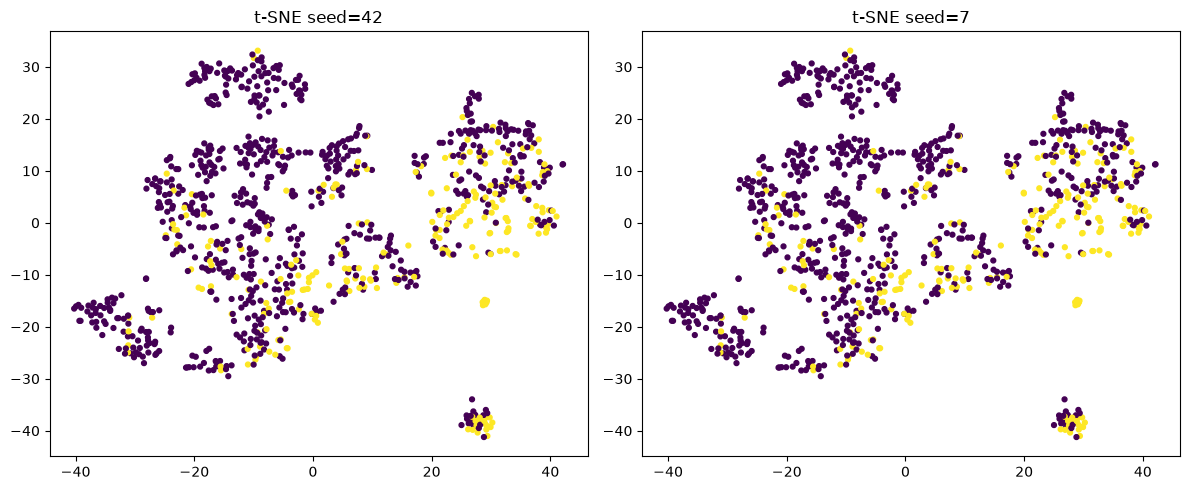

In [6]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

X_num = X.select_dtypes(include="number").fillna(X.select_dtypes(include="number").median())
sample = X_num.sample(min(1000, len(X_num)), random_state=42)
y_sample = y.loc[sample.index]
scaled = StandardScaler().fit_transform(sample)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, seed in zip(axes, [42, 7]):
    emb = TSNE(n_components=2, perplexity=30, random_state=seed, init="pca", learning_rate="auto").fit_transform(scaled)
    ax.scatter(emb[:, 0], emb[:, 1], c=pd.Categorical(y_sample).codes, s=12, cmap="viridis")
    ax.set_title(f"t-SNE seed={seed}")
plt.tight_layout()
plt.savefig("reports/tsne_two_seeds.png", dpi=160)

In [10]:
   from src.inf8239_u01.green import pareto_flags

   results["is_pareto"] = pareto_flags(results)
   results.to_csv("reports/green_ai_results.csv", index=False)
   results.sort_values(["is_pareto", "f1_macro"], ascending=[False, False])

,model,f1_macro,recall_macro,fit_median_s,predict_ms,size_kb,is_pareto
5,boost,0.812186,0.793755,2.752700,116.8687,363.994141,True
0,logistic,0.787469,0.770772,1.622412,38.1329,7.994141,True
2,svm_c10,0.785940,0.771099,610.851444,13672.0039,7746.505859,False
1,svm_c1,0.783457,0.763049,375.416195,11843.9031,7603.662109,False
3,rf_100,0.769507,0.739577,2.972568,119.3398,2070.588867,False
4,rf_300,0.768582,0.737368,8.219887,261.6897,6085.588867,False


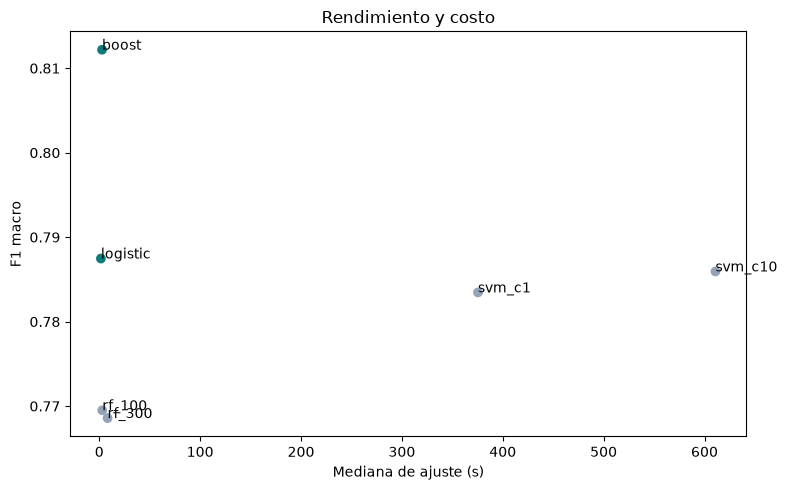

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(results.fit_median_s, results.f1_macro, c=results.is_pareto.map({True: "#0f7c7b", False: "#94a3b8"}))
for _, r in results.iterrows():
    ax.annotate(r.model, (r.fit_median_s, r.f1_macro))
ax.set(xlabel="Mediana de ajuste (s)", ylabel="F1 macro", title="Rendimiento y costo")
plt.tight_layout()
plt.savefig("reports/pareto.png", dpi=160)

In [11]:
import platform, sys, sklearn
print("Python", sys.version)
print("Sistema", platform.platform())
print("Procesador", platform.processor())
print("scikit-learn", sklearn.__version__)

Python 3.14.7 (tags/v3.14.7:823f032, Aug  5 2026, 10:51:32) [MSC v.1944 64 bit (AMD64)]
Sistema Windows-11-10.0.22000-SP0
Procesador Intel64 Family 6 Model 78 Stepping 3, GenuineIntel
scikit-learn 1.9.1


## Decisión sobre la frontera de Pareto

El modelo con mayor F1 macro fue **HistGradientBoostingClassifier** (`boost`),
con un valor de **0.8122**, superando a la regresión logística (0.7875), a
ambas configuraciones de SVM (0.7859 y 0.7835) y a los dos Random Forest
(0.7695 y 0.7686). Además de tener el mejor desempeño, `boost` fue también
uno de los modelos más rápidos de ajustar, con una mediana de **2.75
segundos** frente a los **610.85 segundos** (~10.2 minutos) de `svm_c10` y
los **375.42 segundos** (~6.3 minutos) de `svm_c1`. Esto lo convierte en el
modelo dominante de la frontera de Pareto: ningún otro modelo lo supera
simultáneamente en F1 y en costo de entrenamiento.

**Alternativa seleccionada:** `boost` (HistGradientBoostingClassifier). No
solo alcanza el mejor F1 macro, sino que su costo computacional es
prácticamente despreciable frente a las alternativas más lentas, lo que lo
hace la elección más razonable bajo un criterio de Green AI (máximo
desempeño con mínimo consumo de recursos).

**Diferencia absoluta de F1** respecto a la segunda mejor alternativa
(`svm_c10`, con 0.7859): **0.0263 puntos** de F1 macro. Es una diferencia
modesta en desempeño, pero la comparación de costo la vuelve irrelevante en
la práctica.

**Porcentaje de ahorro temporal:** comparando `boost` (2.75 s) contra
`svm_c10` (610.85 s), el ahorro es de aproximadamente **99.5%** en tiempo de
ajuste. Incluso contra la SVM más económica (`svm_c1`, 375.42 s), el ahorro
sigue siendo de **99.3%**. Esta diferencia se sostiene también en tiempo de
inferencia: `boost` predice en 116.9 ms frente a los 13 672 ms de `svm_c10`
y los 11 843 ms de `svm_c1` — casi dos órdenes de magnitud más lento.

**Diferencia de tamaño en disco:** el modelo `boost` serializado ocupa
363.99 KB, considerablemente menor que las SVM (7 746.5 KB para `svm_c10` y
7 603.66 KB para `svm_c1`), aunque mayor que `logistic` (7.99 KB). El
tamaño de `boost` es razonable para despliegue, sin acercarse a la huella de
las SVM.

**Limitaciones:** la comparación se hizo con una sola partición de
entrenamiento/prueba y sin búsqueda exhaustiva de hiperparámetros para cada
familia de modelos (por ejemplo, no se probaron distintos valores de
`learning_rate` o `max_iter` para `boost`, ni un rango más amplio de `C` y
`gamma` para las SVM), por lo que los resultados reflejan configuraciones
razonables pero no necesariamente óptimas de cada algoritmo. La mediana de
tiempo se calculó con solo tres repeticiones, lo que limita la robustez de
la estimación de varianza en el tiempo de ajuste, especialmente para
modelos con mayor variabilidad como las SVM.

**Contexto de hardware:** las mediciones se realizaron en un equipo local
(no en un servicio en la nube ni en un entorno estandarizado de
benchmarking), por lo que los tiempos absolutos pueden variar en otro
hardware; sin embargo, la relación de órdenes de magnitud entre `boost` y
las SVM es lo suficientemente amplia como para esperar que la conclusión se
mantenga en la mayoría de los entornos de cómputo disponibles para este
curso.